In [139]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt

In [140]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_160226_t1_t2-completada.csv'

In [141]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

#### fixing csv and georreferencing data

TG1: Old thermometer (Sper Scientific 800036)

TG2: new thermometer (TM-188D TENMARS )

In [142]:
df = pd.read_csv(ground_data_path, sep=";")
df

,HORA,TA1,TG1,TA2,TG2,ANEMOMETRO,CONDICION CIELO
0,16:28,"26,3","29,6","26,2","29,6",0,RESOLANA SUAVE
1,16:30,"26,3","32,8","26,2","31,1",0,SOL
2,16:32,"25,8","29,5","25,7","28,4",0,RESOLANA SUAVE
3,16:36,26,"28,9","25,8","27,5",0,RESOLANA SUAVE
4,16:39,"26,3","29,8",26,"28,3",0,RESOLANA FUERTE
5,16:42,"27,4","34,8","27,9","31,6","0,7",RESOLANA MUY FUERTE
6,16:43,"27,4","37,4","27,9","32,4","3,9",SOL
7,16:44,"29,2","43,8","29,5","37,3",0,SOL
8,16:50,"27,1","31,2","26,9","28,9",0,RESOLANA SUAVE
9,16:53,"26,4","30,9","25,9","28,3",0,RESOLANA SUAVE


In [143]:
# convert to numeric

cols = ["TG1", "TG2", "TA1", "TA2", "ANEMOMETRO"]


df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda x: x.str.replace(",", ".", regex=False))
    .apply(pd.to_numeric, errors="coerce")
)

# TG difference
df["dTG"] = df["TG1"] - df["TG2"]


In [144]:
df

,HORA,TA1,TG1,TA2,TG2,ANEMOMETRO,CONDICION CIELO,dTG
0,16:28,26.3,29.6,26.2,29.6,0.0,RESOLANA SUAVE,0.0
1,16:30,26.3,32.8,26.2,31.1,0.0,SOL,1.7
2,16:32,25.8,29.5,25.7,28.4,0.0,RESOLANA SUAVE,1.1
3,16:36,26.0,28.9,25.8,27.5,0.0,RESOLANA SUAVE,1.4
4,16:39,26.3,29.8,26.0,28.3,0.0,RESOLANA FUERTE,1.5
5,16:42,27.4,34.8,27.9,31.6,0.7,RESOLANA MUY FUERTE,3.2
6,16:43,27.4,37.4,27.9,32.4,3.9,SOL,5.0
7,16:44,29.2,43.8,29.5,37.3,0.0,SOL,6.5
8,16:50,27.1,31.2,26.9,28.9,0.0,RESOLANA SUAVE,2.3
9,16:53,26.4,30.9,25.9,28.3,0.0,RESOLANA SUAVE,2.6


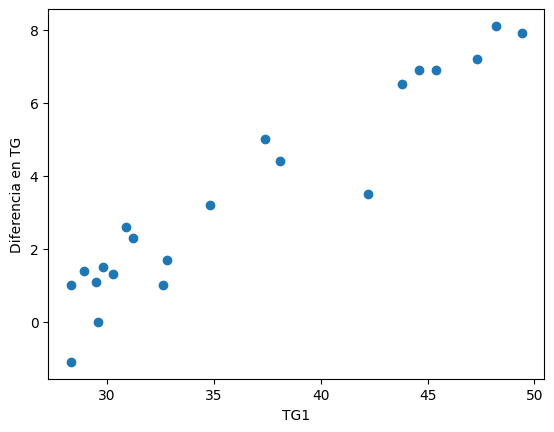

In [145]:
# Scatter: TG1 vs dTG
plt.scatter(df["TG1"], df["dTG"])
plt.xlabel("TG1")
plt.ylabel("Diferencia en TG")
plt.show()

In [146]:
from sklearn.linear_model import LinearRegression

X = df[["TG1"]]   # predictor must be 2D
y = df["TG2"]

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Coefficients
a = model.coef_[0]
b = model.intercept_

print(f"TG1_corr = {a:.3f} * TG1 + {b:.3f}")

# Apply correction: "pass" TG1 to TG2-equivalent
df["TG1_corr"] = a * df["TG1"] + b
df["dTG_CORR"] = df["TG1_corr"] - df["TG2"]

reduction_rmse = (
    1 - np.sqrt((df["dTG_CORR"]**2).mean()) /
        np.sqrt((df["dTG"]**2).mean())
) * 100

print(f"RMSE reduction: {reduction_rmse:.1f} %")


TG1_corr = 0.639 * TG1 + 9.681
RMSE reduction: 81.4 %


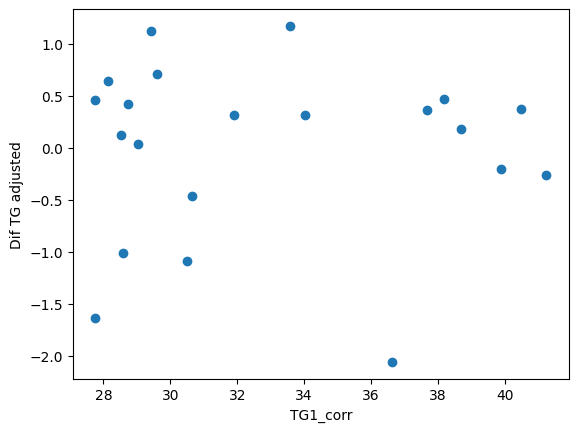

In [147]:
# Scatter: TG1 vs dTG
plt.scatter(df["TG1_corr"], df["dTG_CORR"])
plt.xlabel("TG1_corr")
plt.ylabel("Dif TG adjusted")
plt.show()

In [148]:
import numpy as np

metrics = pd.DataFrame({
    "metric": ["mean", "std", "RMSE", "MAE"],
    "dTG_raw": [
        df["dTG"].mean(),
        df["dTG"].std(),
        np.sqrt((df["dTG"]**2).mean()),
        df["dTG"].abs().mean()
    ],
    "dTG_corr": [
        df["dTG_CORR"].mean(),
        df["dTG_CORR"].std(),
        np.sqrt((df["dTG_CORR"]**2).mean()),
        df["dTG_CORR"].abs().mean()
    ]
})

print(metrics)


  metric   dTG_raw      dTG_corr
0   mean  3.447619  6.767074e-15
1    std  2.826945  8.414298e-01
2   RMSE  4.415557  8.211514e-01
3    MAE  3.552381  6.405925e-01


C:\Users\guada\AppData\Local\Temp\ipykernel_15616\3944679771.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


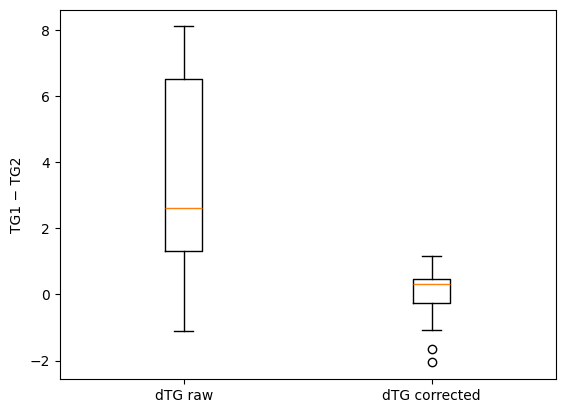

In [149]:
plt.boxplot(
    [df["dTG"].dropna(), df["dTG_CORR"].dropna()],
    labels=["dTG raw", "dTG corrected"]
)
plt.ylabel("TG1 − TG2")
plt.show()


MRT

In [150]:
# Avoid zero wind (ISO recommendation)
df["wind_corr"] = df["ANEMOMETRO"] / 3.6 - 0.88 # convert to m/s and apply correction notebook 3.4.4.4. (subtract 0.88 m/s)
df["wind_corr"] = np.where(df["wind_corr"] <= 0, 0.01, df["wind_corr"])

In [151]:
# compute mean of wind values

df["HORA"] = pd.to_datetime(df["HORA"], errors="coerce") # Convert to datetime
df = df.sort_values("HORA") # Sort by time
df = df.set_index("HORA") # Set as index

# Compute centered rolling mean over 10 minutes (±5 min)
df["wind_mean"] = (
    df["wind_corr"]
    .rolling(window="5min", min_periods=1)
    .mean()
    .round(2)
)

# Reset index 
df = df.reset_index()

C:\Users\guada\AppData\Local\Temp\ipykernel_15616\2281788981.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["HORA"] = pd.to_datetime(df["HORA"], errors="coerce") # Convert to datetime


In [152]:
df

,HORA,TA1,TG1,TA2,TG2,ANEMOMETRO,CONDICION CIELO,dTG,TG1_corr,dTG_CORR,wind_corr,wind_mean
0,2026-03-02 12:24:00,29.9,28.3,29.9,29.4,0.0,SOMBRA,-1.1,27.760492,-1.639508,0.010000,0.01
1,2026-03-02 12:28:00,29.9,49.4,29.9,41.5,0.0,SOL,7.9,41.240243,-0.259757,0.010000,0.01
2,2026-03-02 12:29:00,29.9,48.2,29.9,40.1,0.0,SOL,8.1,40.473622,0.373622,0.010000,0.01
3,2026-03-02 12:30:00,29.9,47.3,29.9,40.1,0.0,SOL,7.2,39.898657,-0.201343,0.010000,0.01
4,2026-03-02 13:18:00,29.3,32.6,28.7,31.6,0.5,SOMBRA,1.0,30.507551,-1.092449,0.010000,0.01
5,2026-03-02 13:40:00,28.9,42.2,30.1,38.7,0.5,SOL,3.5,36.640518,-2.059482,0.010000,0.01
6,2026-03-02 16:28:00,26.3,29.6,26.2,29.6,0.0,RESOLANA SUAVE,0.0,28.590998,-1.009002,0.010000,0.01
7,2026-03-02 16:30:00,26.3,32.8,26.2,31.1,0.0,SOL,1.7,30.635321,-0.464679,0.010000,0.01
8,2026-03-02 16:32:00,25.8,29.5,25.7,28.4,0.0,RESOLANA SUAVE,1.1,28.527113,0.127113,0.010000,0.01
9,2026-03-02 16:36:00,26.0,28.9,25.8,27.5,0.0,RESOLANA SUAVE,1.4,28.143803,0.643803,0.010000,0.01


In [153]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# MRT from TG1
df["MRT1"] = (
    (
        (df["TG1_corr"] + 273.15)**4
        + (1.1e8 * df["wind_corr"]**0.6 / (eps * D1**0.4)) * (df["TG1_corr"] - df["TA1"])
    )**0.25
    - 273.15
)

# MRT from TG2
df["MRT2"] = (
    (
        (df["TG2"] + 273.15)**4
        + (1.1e8 * df["wind_corr"]**0.6 / (eps * D2**0.4)) * (df["TG2"] - df["TA2"])
    )**0.25
    - 273.15
)

# MRT difference
df["dMRT"] = df["MRT1"] - df["MRT2"]


In [154]:
df

,HORA,TA1,TG1,TA2,TG2,ANEMOMETRO,CONDICION CIELO,dTG,TG1_corr,dTG_CORR,wind_corr,wind_mean,MRT1,MRT2,dMRT
0,2026-03-02 12:24:00,29.9,28.3,29.9,29.4,0.0,SOMBRA,-1.1,27.760492,-1.639508,0.010000,0.01,27.239399,29.290646,-2.051247
1,2026-03-02 12:28:00,29.9,49.4,29.9,41.5,0.0,SOL,7.9,41.240243,-0.259757,0.010000,0.01,43.628357,43.730390,-0.102033
2,2026-03-02 12:29:00,29.9,48.2,29.9,40.1,0.0,SOL,8.1,40.473622,0.373622,0.010000,0.01,42.718141,42.089813,0.628328
3,2026-03-02 12:30:00,29.9,47.3,29.9,40.1,0.0,SOL,7.2,39.898657,-0.201343,0.010000,0.01,42.033915,42.089813,-0.055898
4,2026-03-02 13:18:00,29.3,32.6,28.7,31.6,0.5,SOMBRA,1.0,30.507551,-1.092449,0.010000,0.01,30.792604,32.218395,-1.425791
5,2026-03-02 13:40:00,28.9,42.2,30.1,38.7,0.5,SOL,3.5,36.640518,-2.059482,0.010000,0.01,38.349582,40.402657,-2.053074
6,2026-03-02 16:28:00,26.3,29.6,26.2,29.6,0.0,RESOLANA SUAVE,0.0,28.590998,-1.009002,0.010000,0.01,29.141449,30.339023,-1.197573
7,2026-03-02 16:30:00,26.3,32.8,26.2,31.1,0.0,SOL,1.7,30.635321,-0.464679,0.010000,0.01,31.653731,32.147810,-0.494079
8,2026-03-02 16:32:00,25.8,29.5,25.7,28.4,0.0,RESOLANA SUAVE,1.1,28.527113,0.127113,0.010000,0.01,29.182422,28.994324,0.188099
9,2026-03-02 16:36:00,26.0,28.9,25.8,27.5,0.0,RESOLANA SUAVE,1.4,28.143803,0.643803,0.010000,0.01,28.661267,27.877979,0.783288


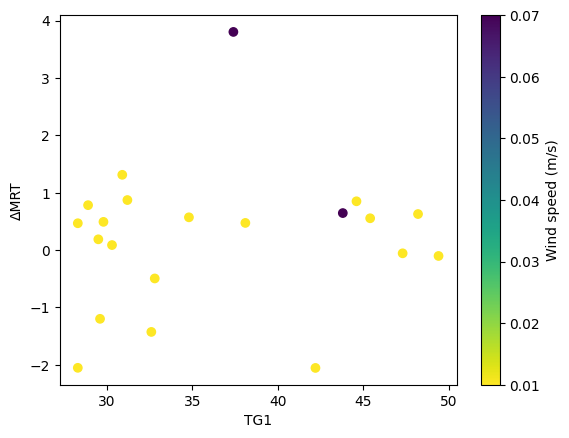

In [156]:
plt.scatter(
    df["TG1"],
    df["dMRT"],
    c=df["wind_mean"],
    cmap="viridis_r"
)

plt.xlabel("TG1")
plt.ylabel("ΔMRT")

cbar = plt.colorbar()
cbar.set_label("Wind speed (m/s)")

plt.show()


not working so good. Better take points with no wind